# 03. Modelagem com SVM para Detecção de Anomalias

**Objetivo:** Este notebook implementa um modelo de **Support Vector Machine (SVM)** para a detecção de anomalias nos logs de servidor.

**Metodologia:**
1.  **Carregamento dos Dados:** Os dados pré-processados pelo notebook `01-EDA-ServerLogs.ipynb` serão carregados.
2.  **Divisão Estratégica:** Os dados serão divididos em conjuntos de **treino (70%)**, **validação (10%)** e **teste (20%)** para garantir uma avaliação robusta.
3.  **Busca de Hiperparâmetros:** Testaremos diferentes valores para os hiperparâmetros `C` e `gamma` do SVM, avaliando o desempenho no conjunto de validação.
4.  **Otimização do Limiar:** Após encontrar os melhores hiperparâmetros, faremos um ajuste fino no limiar de decisão para otimizar o F1-Score.
5.  **Avaliação Final:** O modelo final será treinado nos dados de treino e validação combinados e avaliado uma única vez no conjunto de teste.

In [1]:
# --- Importações Essenciais ---
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# --- Importações do Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from scipy import sparse
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    auc
)

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# --- Carregamento e Divisão dos Dados ---

# Definir o caminho para os dados processados pelo notebook de EDA
processed_data_path = '../../data/processed/cidds_dataset'
train_proc_path = os.path.join(processed_data_path, 'train_processed.npz')
test_proc_path = os.path.join(processed_data_path, 'test_processed.npz')

# Carregar os arrays NumPy
# O conjunto de treino do EDA (70%) será usado para treino e validação aqui.
train_val_data = np.load(train_proc_path, allow_pickle=True)
# O conjunto de teste do EDA (30%) será nosso teste final.
test_data = np.load(test_proc_path, allow_pickle=True)

# O conjunto de teste já está separado e pronto.
X_test = test_data['X'].item()
y_test = test_data['y']
X_full = train_val_data['X'].item()
y_full = train_val_data['y']

# Agora, vamos dividir o `train_val_data` em treino e validação.
# Proporção: (7/10) do `train_val_data` para treino e (3/10) para validação
# Isso resultará em 70% (treino) e 30% (validação) do conjunto de treino original do EDA.
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.30,  # 30% do conjunto de treino do EDA para validação
    random_state=42,
    stratify=y_full
)

# Verificar as dimensões finais
print("Divisão final dos dados:")
print(f"Treino (X, y):    \t{X_train.shape}, {y_train.shape}")
print(f"Validação (X, y): \t{X_val.shape}, {y_val.shape}")
print(f"Teste (X, y):     \t{X_test.shape}, {y_test.shape}")

Divisão final dos dados:
Treino (X, y):    	(74152, 293), (74152,)
Validação (X, y): 	(31780, 293), (31780,)
Teste (X, y):     	(45400, 293), (45400,)


In [3]:
# --- Grid Search Manual para o SVM ---

# Grade de hiperparâmetros a ser explorada
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 1, 0.1]
}

results_list = []
total_runs = len(param_grid['C']) * len(param_grid['gamma'])
current_run = 0

print(f"Iniciando a busca em grade... Total de {total_runs} execuções.")

for C_val in param_grid['C']:
    for gamma_val in param_grid['gamma']:
        current_run += 1
        print(f"Execução {current_run}/{total_runs}: C={C_val}, gamma={gamma_val}")
        
        # Instanciar o modelo SVM
        model = SVC(
            C=C_val,
            gamma=gamma_val,
            kernel='rbf',
            class_weight='balanced',  # Importante para dados desbalanceados
            probability=True,         # Necessário para otimizar o limiar depois
            random_state=42
        )
        
        # Treinar o modelo e medir o tempo
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Fazer previsões no conjunto de validação (usando limiar padrão 0.5)
        y_pred_val = model.predict(X_val)
        
        # Calcular as métricas
        f1 = f1_score(y_val, y_pred_val)
        precision = precision_score(y_val, y_pred_val, zero_division=0)
        recall = recall_score(y_val, y_pred_val, zero_division=0)
        
        # Armazenar os resultados
        results_list.append({
            'C': C_val,
            'gamma': gamma_val,
            'train_time': train_time,
            'f1_score': f1,
            'precision': precision,
            'recall': recall
        })

print("\nBusca em grade concluída!")

# Analisar os resultados
results_df = pd.DataFrame(results_list)
best_params_row = results_df.sort_values(by='f1_score', ascending=False).iloc[0]
best_params = best_params_row.to_dict()

print("\n--- Melhores Hiperparâmetros Encontrados (baseado no F1-Score) ---")
print(best_params)

Iniciando a busca em grade... Total de 9 execuções.
Execução 1/9: C=0.1, gamma=scale
Execução 2/9: C=0.1, gamma=1
Execução 3/9: C=0.1, gamma=0.1
Execução 4/9: C=1, gamma=scale
Execução 5/9: C=1, gamma=1
Execução 6/9: C=1, gamma=0.1
Execução 7/9: C=10, gamma=scale
Execução 8/9: C=10, gamma=1
Execução 9/9: C=10, gamma=0.1

Busca em grade concluída!

--- Melhores Hiperparâmetros Encontrados (baseado no F1-Score) ---
{'C': 10.0, 'gamma': 0.1, 'train_time': 10.256999254226685, 'f1_score': 0.9998596556886228, 'precision': 0.9997193507647691, 'recall': 1.0}


Treinando um modelo SVM com os melhores parâmetros para otimizar o limiar...

Melhor Limiar encontrado: 0.5766
F1-Score correspondente no conjunto de validação: 0.9999


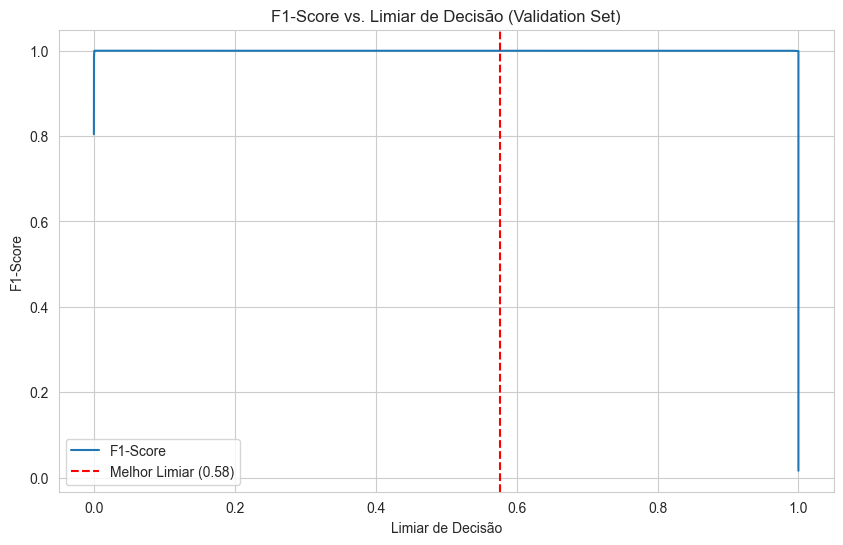

In [4]:
# --- Otimização do Limiar de Decisão com os Melhores Hiperparâmetros ---

print("Treinando um modelo SVM com os melhores parâmetros para otimizar o limiar...")

# Instanciar o modelo com os melhores parâmetros encontrados
svm_for_tuning = SVC(
    C=best_params['C'],
    gamma=best_params['gamma'],
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_for_tuning.fit(X_train, y_train)

# Obter as probabilidades de previsão para a classe positiva (Anomalia) no conjunto de validação
y_probs_val = svm_for_tuning.predict_proba(X_val)[:, 1]

# Calcular precisão, recall e limiares
precision, recall, thresholds = precision_recall_curve(y_val, y_probs_val)

# Adicionar um epsilon para evitar divisão por zero no cálculo do F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

# Encontrar o melhor limiar que maximiza o F1-score
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"\nMelhor Limiar encontrado: {best_threshold:.4f}")
print(f"F1-Score correspondente no conjunto de validação: {best_f1:.4f}")

# Plotar a curva F1-Score vs. Limiar
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel("Limiar de Decisão")
plt.ylabel("F1-Score")
plt.title("F1-Score vs. Limiar de Decisão (Validation Set)")
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.legend()
plt.show()

Formato do conjunto de treino final (X, y): (105932, 293), (105932,)

Treinando o modelo final...
Treino concluído em 19.59 segundos.

--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     14866
    Anomalia       1.00      1.00      1.00     30534

    accuracy                           1.00     45400
   macro avg       1.00      1.00      1.00     45400
weighted avg       1.00      1.00      1.00     45400


--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---


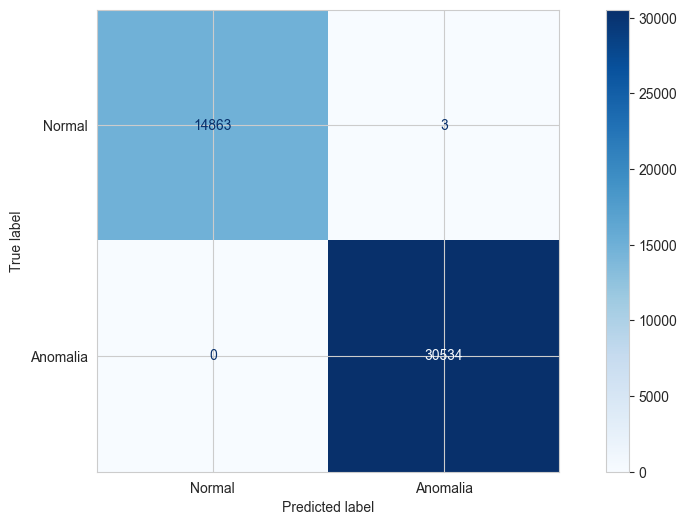


ROC AUC (Teste): 1.0000
PR AUC (Teste): 1.0000


In [5]:
# --- Treino e Avaliação do Modelo Final ---

# Combinar dados de treino e validação para o treino final
X_train_full = sparse.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

print(f"Formato do conjunto de treino final (X, y): {X_train_full.shape}, {y_train_full.shape}")

# Instanciar o modelo final com os melhores hiperparâmetros
final_model = SVC(
    C=best_params['C'],
    gamma=best_params['gamma'],
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)

# Treinar o modelo final
print("\nTreinando o modelo final...")
start_time = time.time()
final_model.fit(X_train_full, y_train_full)
print(f"Treino concluído em {time.time() - start_time:.2f} segundos.")

# Obter as probabilidades no conjunto de teste
y_pred_test_probs = final_model.predict_proba(X_test)[:, 1]

# Aplicar o melhor limiar encontrado na etapa de validação
y_pred_test_tuned = (y_pred_test_probs >= best_threshold).astype(int)

# Avaliar o desempenho final
print("\n--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_test_tuned, target_names=['Normal', 'Anomalia']))

# Visualizar a Matriz de Confusão Final
print("\n--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---")
cm_tuned = confusion_matrix(y_test, y_pred_test_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Normal', 'Anomalia'])
disp_tuned.plot(cmap=plt.cm.Blues)
plt.show()

# Métricas AUC no conjunto de teste
roc_auc_test = roc_auc_score(y_test, y_pred_test_probs)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_pred_test_probs)
pr_auc_test = auc(recall_test, precision_test)
print(f"\nROC AUC (Teste): {roc_auc_test:.4f}")
print(f"PR AUC (Teste): {pr_auc_test:.4f}")